In [10]:
import os
os.makedirs("data/05_dataset_versions_updated", exist_ok=True)

In [25]:
import pandas as pd
import numpy as np
from glob import glob

events = pd.read_csv("events_step3_ok_updated.csv")
events["filing_date"] = pd.to_datetime(events["filing_date"], errors="coerce")

# remove bad dates if any
events = events.dropna(subset=["filing_date"]).copy()

print("Events shape:", events.shape)
events.head()

Events shape: (2265, 13)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,text_length_words,mda_status,primary_doc
0,AAPL,320193,2019-01-30,10-Q,0000320193-19-000010,2019,1,320193,32019319000010,AAPL_20190130_10-Q_000032019319000010.txt,8130,OK,a10-qq1201912292018.htm
1,AAPL,320193,2019-05-01,10-Q,0000320193-19-000066,2019,2,320193,32019319000066,AAPL_20190501_10-Q_000032019319000066.txt,8286,OK,a10-qq220193302019.htm
2,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,8166,OK,a10-qq320196292019.htm
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,3926,OK,a10-qq1202012282019.htm
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,5146,OK,a10-qq220203282020.htm


In [26]:
import zipfile
import os

zip_path = "ticker_price_files_filtered_updated.zip"
extract_dir = "data/04_prices/ticker_price_files_filtered_updated"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", len(os.listdir(extract_dir)))
print(os.listdir(extract_dir)[:10])

Extracted files: 123
['DIS.csv', 'GILD.csv', 'SPGI.csv', 'AMZN.csv', 'APH.csv', 'UBER.csv', 'T.csv', 'CME.csv', 'BA.csv', 'MDLZ.csv']


In [27]:
from glob import glob
import os
import pandas as pd

price_files = glob("data/04_prices/ticker_price_files_filtered_updated/*.csv")

price_data = {}

for fp in price_files:
    ticker = os.path.basename(fp).replace(".csv", "")
    df = pd.read_csv(fp)

    # standardise date
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # standardise return column name if needed
    if "ret" in df.columns and "return" not in df.columns:
        df = df.rename(columns={"ret": "return"})

    # clean numeric columns
    df["return"] = pd.to_numeric(df["return"], errors="coerce")
    df["adj_close"] = pd.to_numeric(df["adj_close"], errors="coerce")

    # keep only valid rows
    df = df.dropna(subset=["date", "adj_close", "return"]).copy()

    # sort and remove duplicate dates
    df = df.sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)

    price_data[ticker] = df

print("Loaded price files:", len(price_data))
print("Example tickers:", list(price_data.keys())[:10])

Loaded price files: 123
Example tickers: ['DIS', 'GILD', 'SPGI', 'AMZN', 'APH', 'UBER', 'T', 'CME', 'BA', 'MDLZ']


In [28]:
event_tickers = set(events["ticker"].astype(str).str.strip().str.upper().unique())
price_tickers = set(price_data.keys())

print("Tickers in events:", len(event_tickers))
print("Tickers in prices:", len(price_tickers))
print("Missing price files:", len(event_tickers - price_tickers))
print("Missing tickers list:", sorted(list(event_tickers - price_tickers))[:20])

Tickers in events: 124
Tickers in prices: 123
Missing price files: 1
Missing tickers list: ['BRK.B']


In [29]:
def cumulative_return(returns):
    return np.prod(1 + returns) - 1

def realized_volatility(returns):
    return np.std(returns, ddof=1)

In [30]:
rows = []
dropped = []

for _, row in events.iterrows():
    ticker = str(row["ticker"]).strip().upper()
    filing_date = row["filing_date"]

    # skip if no price file
    if ticker not in price_data:
        dropped.append((ticker, filing_date, "NO_PRICE_FILE"))
        continue

    px = price_data[ticker]

    # strictly before filing date
    past = px[px["date"] < filing_date].copy()

    # strictly after filing date
    future = px[px["date"] > filing_date].copy()

    # require enough trading days
    if len(past) < 10:
        dropped.append((ticker, filing_date, "NOT_ENOUGH_PAST"))
        continue

    if len(future) < 10:
        dropped.append((ticker, filing_date, "NOT_ENOUGH_FUTURE"))
        continue

    # windows
    past_10 = past.tail(10)
    past_5 = past.tail(5)
    future_10 = future.head(10)

    # compute variables
    past_return_10d = cumulative_return(past_10["return"].values)
    past_realized_vol_5d = realized_volatility(past_5["return"].values)
    past_realized_vol_10d = realized_volatility(past_10["return"].values)
    future_realized_vol_10d = realized_volatility(future_10["return"].values)

    new_row = row.to_dict()
    new_row["past_return_10d"] = past_return_10d
    new_row["past_realized_vol_5d"] = past_realized_vol_5d
    new_row["past_realized_vol_10d"] = past_realized_vol_10d
    new_row["future_realized_vol_10d"] = future_realized_vol_10d

    rows.append(new_row)

In [31]:
dataset_v1 = pd.DataFrame(rows)

print("dataset_v1 shape before final clean:", dataset_v1.shape)
dataset_v1.head()

dataset_v1 shape before final clean: (2247, 17)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,text_length_words,mda_status,primary_doc,past_return_10d,past_realized_vol_5d,past_realized_vol_10d,future_realized_vol_10d
0,AAPL,320193,2019-01-30,10-Q,0000320193-19-000010,2019,1,320193,32019319000010,AAPL_20190130_10-Q_000032019319000010.txt,8130,OK,a10-qq1201912292018.htm,0.031200,0.018383,0.016375,0.012985
1,AAPL,320193,2019-05-01,10-Q,0000320193-19-000066,2019,2,320193,32019319000066,AAPL_20190501_10-Q_000032019319000066.txt,8286,OK,a10-qq220193302019.htm,0.007228,0.008079,0.010983,0.022134
2,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,8166,OK,a10-qq320196292019.htm,0.020931,0.006725,0.011068,0.028255
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,3926,OK,a10-qq1202012282019.htm,0.002303,0.020648,0.015755,0.021234
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,5146,OK,a10-qq220203282020.htm,0.024802,0.020703,0.023482,0.012307


In [32]:
dataset_v1 = dataset_v1.dropna(subset=[
    "past_return_10d",
    "past_realized_vol_5d",
    "past_realized_vol_10d",
    "future_realized_vol_10d"
]).copy()

print("dataset_v1 shape after final clean:", dataset_v1.shape)

dataset_v1 shape after final clean: (2247, 17)


In [33]:
dataset_v1["abs_past_return_10d"] = dataset_v1["past_return_10d"].abs()

print("abs_past_return_10d added")
dataset_v1[["past_return_10d", "abs_past_return_10d"]].head()

abs_past_return_10d added


,past_return_10d,abs_past_return_10d
0,0.031200,0.031200
1,0.007228,0.007228
2,0.020931,0.020931
3,0.002303,0.002303
4,0.024802,0.024802


In [34]:
dropped_df = pd.DataFrame(dropped, columns=["ticker", "filing_date", "reason"])
dropped_df.to_csv("data/05_dataset_versions_updated/dropped_step5_rows_updated.csv", index=False)

print(dropped_df["reason"].value_counts())
dropped_df.head()

reason
NOT_ENOUGH_PAST      13
NOT_ENOUGH_FUTURE     3
NO_PRICE_FILE         2
Name: count, dtype: int64


,ticker,filing_date,reason
0,AVGO,2024-12-20,NOT_ENOUGH_FUTURE
1,BRK.B,2021-05-03,NO_PRICE_FILE
2,BRK.B,2024-05-06,NO_PRICE_FILE
3,COST,2024-12-19,NOT_ENOUGH_FUTURE
4,CTAS,2019-01-08,NOT_ENOUGH_PAST


In [35]:
dataset_v1["acc_nodash"] = dataset_v1["acc_nodash"].astype(str).str.zfill(18)

dataset_v1.to_csv(
    "data/05_dataset_versions_updated/dataset_v1_price_only_updated.csv",
    index=False
)

print("Saved: data/05_dataset_versions_updated/dataset_v1_price_only_updated.csv")
dataset_v1["acc_nodash"].head()

Saved: data/05_dataset_versions_updated/dataset_v1_price_only_updated.csv


,acc_nodash
0,000032019319000010
1,000032019319000066
2,000032019319000076
3,000032019320000010
4,000032019320000052


In [36]:
dataset_model = dataset_v1[
    [
        "ticker",
        "filing_date",
        "filing_type",
        "year",
        "quarter",
        "text_length_words",
        "past_return_10d",
        "abs_past_return_10d",
        "past_realized_vol_5d",
        "past_realized_vol_10d",
        "future_realized_vol_10d"
    ]
].copy()

dataset_model = dataset_model.sort_values(
    ["ticker", "filing_date"]
).reset_index(drop=True)

dataset_model.to_csv(
    "data/05_dataset_versions_updated/dataset_v1_model_ready_updated.csv",
    index=False
)

print("Saved: data/05_dataset_versions_updated/dataset_v1_model_ready_updated.csv")
dataset_model.head()

Saved: data/05_dataset_versions_updated/dataset_v1_model_ready_updated.csv


,ticker,filing_date,filing_type,year,quarter,text_length_words,past_return_10d,abs_past_return_10d,past_realized_vol_5d,past_realized_vol_10d,future_realized_vol_10d
0,AAPL,2019-01-30,10-Q,2019,1,8130,0.031200,0.031200,0.018383,0.016375,0.012985
1,AAPL,2019-05-01,10-Q,2019,2,8286,0.007228,0.007228,0.008079,0.010983,0.022134
2,AAPL,2019-07-31,10-Q,2019,3,8166,0.020931,0.020931,0.006725,0.011068,0.028255
3,AAPL,2019-10-31,10-K,2019,4,1029,0.037932,0.037932,0.014049,0.011403,0.009771
4,AAPL,2020-01-29,10-Q,2020,1,3926,0.002303,0.002303,0.020648,0.015755,0.021234


In [37]:
corr = dataset_v1[
    [
        "past_return_10d",
        "abs_past_return_10d",
        "past_realized_vol_5d",
        "past_realized_vol_10d",
        "future_realized_vol_10d"
    ]
].corr()

print(corr)

                         past_return_10d  abs_past_return_10d  \
past_return_10d                 1.000000             0.296161   
abs_past_return_10d             0.296161             1.000000   
past_realized_vol_5d            0.031321             0.456391   
past_realized_vol_10d           0.066715             0.538952   
future_realized_vol_10d        -0.075661             0.305732   

                         past_realized_vol_5d  past_realized_vol_10d  \
past_return_10d                      0.031321               0.066715   
abs_past_return_10d                  0.456391               0.538952   
past_realized_vol_5d                 1.000000               0.839108   
past_realized_vol_10d                0.839108               1.000000   
future_realized_vol_10d              0.446305               0.503447   

                         future_realized_vol_10d  
past_return_10d                        -0.075661  
abs_past_return_10d                     0.305732  
past_realized_vol_5d   

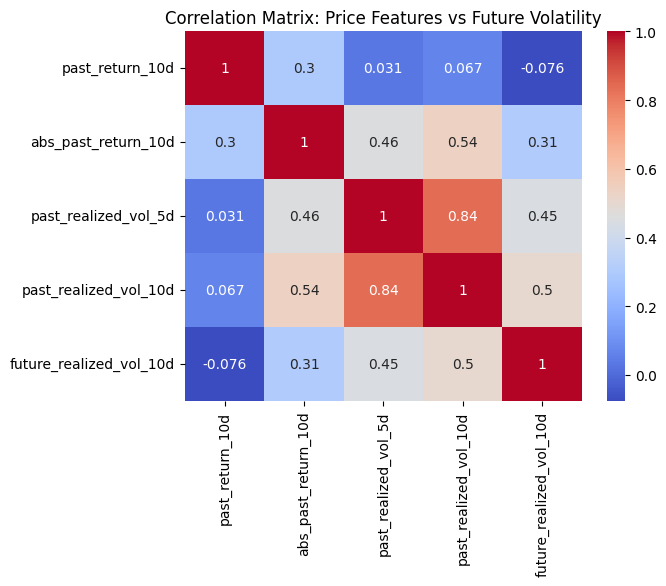

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix: Price Features vs Future Volatility")
plt.show()

In [39]:
audit_rows = []

for _, row in dataset_v1.head(10).iterrows():
    ticker = row["ticker"]
    filing_date = pd.to_datetime(row["filing_date"])
    px = price_data[ticker]

    past = px[px["date"] < filing_date].copy()
    future = px[px["date"] > filing_date].copy()

    past_10 = past.tail(10)
    future_10 = future.head(10)

    audit_rows.append({
        "ticker": ticker,
        "filing_date": filing_date,
        "past_start": past_10["date"].min(),
        "past_end": past_10["date"].max(),
        "future_start": future_10["date"].min(),
        "future_end": future_10["date"].max()
    })

audit_df = pd.DataFrame(audit_rows)
audit_df

,ticker,filing_date,past_start,past_end,future_start,future_end
0,AAPL,2019-01-30,2019-01-15,2019-01-29,2019-01-31,2019-02-13
1,AAPL,2019-05-01,2019-04-16,2019-04-30,2019-05-02,2019-05-15
2,AAPL,2019-07-31,2019-07-17,2019-07-30,2019-08-01,2019-08-14
3,AAPL,2020-01-29,2020-01-14,2020-01-28,2020-01-30,2020-02-12
4,AAPL,2020-05-01,2020-04-17,2020-04-30,2020-05-04,2020-05-15
5,AAPL,2020-07-31,2020-07-17,2020-07-30,2020-08-03,2020-08-14
6,AAPL,2021-01-28,2021-01-13,2021-01-27,2021-01-29,2021-02-11
7,AAPL,2021-04-29,2021-04-15,2021-04-28,2021-04-30,2021-05-13
8,AAPL,2021-07-28,2021-07-14,2021-07-27,2021-07-29,2021-08-11
9,AAPL,2022-01-28,2022-01-13,2022-01-27,2022-01-31,2022-02-11


In [40]:
audit_df["past_ok"] = audit_df["past_end"] < audit_df["filing_date"]
audit_df["future_ok"] = audit_df["future_start"] > audit_df["filing_date"]

audit_df

,ticker,filing_date,past_start,past_end,future_start,future_end,past_ok,future_ok
0,AAPL,2019-01-30,2019-01-15,2019-01-29,2019-01-31,2019-02-13,True,True
1,AAPL,2019-05-01,2019-04-16,2019-04-30,2019-05-02,2019-05-15,True,True
2,AAPL,2019-07-31,2019-07-17,2019-07-30,2019-08-01,2019-08-14,True,True
3,AAPL,2020-01-29,2020-01-14,2020-01-28,2020-01-30,2020-02-12,True,True
4,AAPL,2020-05-01,2020-04-17,2020-04-30,2020-05-04,2020-05-15,True,True
5,AAPL,2020-07-31,2020-07-17,2020-07-30,2020-08-03,2020-08-14,True,True
6,AAPL,2021-01-28,2021-01-13,2021-01-27,2021-01-29,2021-02-11,True,True
7,AAPL,2021-04-29,2021-04-15,2021-04-28,2021-04-30,2021-05-13,True,True
8,AAPL,2021-07-28,2021-07-14,2021-07-27,2021-07-29,2021-08-11,True,True
9,AAPL,2022-01-28,2022-01-13,2022-01-27,2022-01-31,2022-02-11,True,True


In [41]:
audit_df.to_csv("data/05_dataset_versions_updated/window_audit_step5_updated.csv", index=False)

print("Saved: data/05_dataset_versions_updated/window_audit_step5_updated.csv")
print(audit_df["past_ok"].all())
print(audit_df["future_ok"].all())

Saved: data/05_dataset_versions_updated/window_audit_step5_updated.csv
True
True


In [42]:
print("Events input rows:", len(events))
print("Dataset_v1 rows:", len(dataset_v1))
print("Dropped rows:", len(dropped_df))

print(dropped_df["reason"].value_counts())

print(dataset_v1[
    [
        "past_return_10d",
        "past_realized_vol_5d",
        "past_realized_vol_10d",
        "future_realized_vol_10d"
    ]
].describe())

Events input rows: 2265
Dataset_v1 rows: 2247
Dropped rows: 18
reason
NOT_ENOUGH_PAST      13
NOT_ENOUGH_FUTURE     3
NO_PRICE_FILE         2
Name: count, dtype: int64
       past_return_10d  past_realized_vol_5d  past_realized_vol_10d  \
count      2247.000000           2247.000000            2247.000000   
mean          0.013469              0.018604               0.019021   
std           0.068331              0.014243               0.012178   
min          -0.369860              0.001083               0.002646   
25%          -0.023441              0.009777               0.011197   
50%           0.010928              0.014787               0.015914   
75%           0.047508              0.023004               0.023185   
max           0.435958              0.187618               0.130407   

       future_realized_vol_10d  
count              2247.000000  
mean                  0.018105  
std                   0.011732  
min                   0.003724  
25%                   0.010

In [43]:
print("Negative past_realized_vol_5d:", (dataset_v1["past_realized_vol_5d"] < 0).sum())
print("Negative past_realized_vol_10d:", (dataset_v1["past_realized_vol_10d"] < 0).sum())
print("Negative future_realized_vol_10d:", (dataset_v1["future_realized_vol_10d"] < 0).sum())

Negative past_realized_vol_5d: 0
Negative past_realized_vol_10d: 0
Negative future_realized_vol_10d: 0


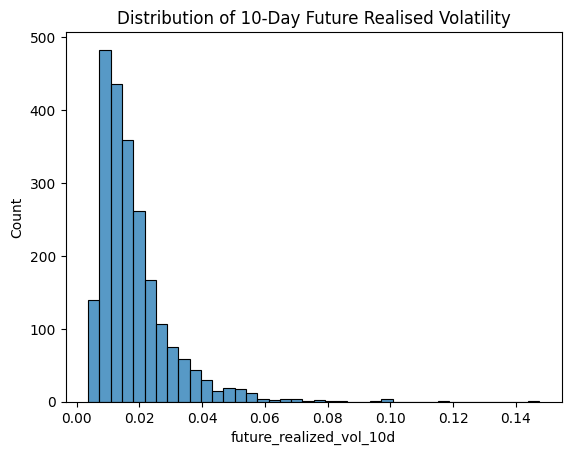

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(dataset_v1["future_realized_vol_10d"], bins=40)
plt.title("Distribution of 10-Day Future Realised Volatility")
plt.show()

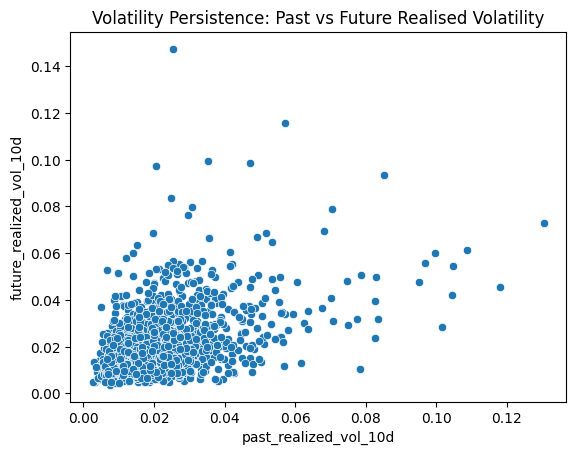

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=dataset_v1["past_realized_vol_10d"],
    y=dataset_v1["future_realized_vol_10d"]
)
plt.title("Volatility Persistence: Past vs Future Realised Volatility")
plt.show()

In [46]:
from google.colab import files

files.download("data/05_dataset_versions_updated/dataset_v1_price_only_updated.csv")
files.download("data/05_dataset_versions_updated/dataset_v1_model_ready_updated.csv")
files.download("data/05_dataset_versions_updated/dropped_step5_rows_updated.csv")
files.download("data/05_dataset_versions_updated/window_audit_step5_updated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>